In [1]:
import sys
sys.path.append('/gpfs/work/aac/xingyiyao23/Code/')
import SimpleITK as sitk
import glob
import os
import glob
import lpips
import torch
import numpy as np
import pandas as pd
import nibabel as nb
from skimage.metrics import structural_similarity
import matplotlib.pyplot as plt


import Diffusion_denoising_thin_slice.functions_collection as ff
import Diffusion_denoising_thin_slice.Build_lists.Build_list as Build_list

/opt/conda/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
build_sheet =  Build_list.Build_thinsliceCT(os.path.join('/gpfs/work/aac/xingyiyao23/Data/brain_CT/Patient_lists/fixedCT_static_simulation_train_test_gaussian_xjtlu.xlsx'))
_,patient_id_list,patient_subid_list,random_num_list, condition_list, x0_list = build_sheet.__build__(batch_list = [5]) 
print('total cases:', patient_id_list.shape[0])
n = ff.get_X_numbers_in_interval(total_number = patient_id_list.shape[0],start_number = 0,end_number = 1, interval = 2)
print('total number:', n.shape[0])

total cases: 32
total number: 16


In [6]:
def calc_mae_with_ref_window(img, ref, vmin, vmax):
    maes = []
    for slice_num in range(0, img.shape[-1]):
        slice_img = img[:,:,slice_num]
        slice_ref = ref[:,:,slice_num]
        mask = np.where((slice_ref >= vmin) & (slice_ref <= vmax), 1, 0)
        mae = np.sum(np.abs(slice_img - slice_ref) * mask) / np.sum(mask)
        maes.append(mae)

    return np.mean(maes), np.std(maes)

def calc_ssim_with_ref_window(img, ref, vmin, vmax):

    ssims = []
    for slice_num in range(0, img.shape[-1]):
        slice_img = img[:,:,slice_num]
        slice_ref = ref[:,:,slice_num]
        mask = np.where((slice_ref >= vmin) & (slice_ref <= vmax), 1, 0)
        _, ssim_map = structural_similarity(slice_img, slice_ref, data_range=vmax - vmin, full=True)
        ssim = np.sum(ssim_map * mask) / np.sum(mask)
        ssims.append(ssim)

    return np.mean(ssims), np.std(ssims)

def calc_lpips(imgs1, imgs2, vmin, vmax):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    loss_fn = lpips.LPIPS().to(device)
    
    lpipss = []
    for slice_num in range(0, imgs1.shape[-1]):
        slice1 = imgs1[:,:,slice_num]
        slice2 = imgs2[:,:,slice_num]

        slice1 = np.clip(slice1, vmin, vmax).astype(np.float32)
        slice2 = np.clip(slice2, vmin, vmax).astype(np.float32)

        slice1 = (slice1 - vmin) / (vmax - vmin) * 2 - 1
        slice2 = (slice2 - vmin) / (vmax - vmin) * 2 - 1

        slice1 = np.stack([slice1, slice1, slice1], axis=-1)
        slice2 = np.stack([slice2, slice2, slice2], axis=-1)
        # print('after stack, slice1 shape:', slice1.shape, ' slice2 shape:', slice2.shape)

        slice1 = np.transpose(slice1, (2, 0, 1))[np.newaxis, ...]
        slice2 = np.transpose(slice2, (2, 0, 1))[np.newaxis, ...]
        # print('after transpose, slice1 shape:', slice1.shape, ' slice2 shape:', slice2.shape)

        slice1 = torch.from_numpy(slice1).to(device)
        slice2 = torch.from_numpy(slice2).to(device)

        lpips_val = loss_fn(slice1, slice2)
        lpipss.append(lpips_val.item())

      

    return np.mean(lpipss), np.std(lpipss)


In [7]:
num_inferences = [1, 2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20]

mae_list = []
ssim_list = []

for i in range(0, len(num_inferences)):
    n_infer = num_inferences[i]
    print(f'Number of inferences: {n_infer}')

    mae_for_this_infer = []
    ssim_for_this_infer = []

    for j in range(0, len(n)):

        patient_id = patient_id_list[n[j]]
        patient_subid = patient_subid_list[n[j]]
        random_n = random_num_list[n[j]]
        print(patient_id,  patient_subid, random_n)

        # reference image
        gt_file =  os.path.join('/gpfs/work/aac/xingyiyao23/projects/unsupervised_gaussian_brainCT/pred_images', patient_id, patient_subid,'random_'+str(random_n), 'epoch61_1/gt_img.nii.gz')
        gt_img = nb.load(gt_file).get_fdata()

        # # our method 
        # if n_infer != 1:
        unsupervised_beta0_avg_file = os.path.join('/gpfs/work/aac/xingyiyao23/projects/unsupervised_gaussian_brainCT/pred_images', patient_id,patient_subid, 'random_'+str(random_n), 'epoch61avg/pred_img_scans' + str(n_infer) + '.nii.gz')
        unsupervised_beta0_avg_img = nb.load(unsupervised_beta0_avg_file).get_fdata()
        # else:
        #     unsupervised_beta0_avg_file = os.path.join('/gpfs/work/aac/xingyiyao23/projects/unsupervised_gaussian_2/pred_images_input_both', patient_id,'random_'+str(random_n), 'epoch105_1/pred_img.nii.gz')
        #     unsupervised_beta0_avg_img = nb.load(unsupervised_beta0_avg_file).get_fdata()

        vmin = 0
        vmax = 100
        mae_case,_= calc_mae_with_ref_window(unsupervised_beta0_avg_img, gt_img, vmin, vmax)
        ssim_case, _ = calc_ssim_with_ref_window(unsupervised_beta0_avg_img, gt_img, vmin, vmax)
        print(f'MAE: {mae_case}, SSIM: {ssim_case}')

        mae_for_this_infer.append(mae_case)
        ssim_for_this_infer.append(ssim_case)
    print('mae for this inference:', mae_for_this_infer, 'ssim for this inference:', ssim_for_this_infer)

    mae_list.append(np.mean(mae_for_this_infer))
    ssim_list.append(np.mean(ssim_for_this_infer))

# save it into a dataframe
df = pd.DataFrame({'num_inferences': num_inferences, 'MAE': mae_list, 'SSIM': ssim_list})
df.to_excel('/host/d/projects/denoising/results/multiple_inference_analysis_brainCT.xlsx', index=False)


Number of inferences: 1
00214841 0000455418 0
MAE: 4.9903326804242365, SSIM: 0.411119739757146
00105734 0000455323 0
MAE: 5.638568477761703, SSIM: 0.3934165410481221
00214867 0000455521 0
MAE: 5.626173344633871, SSIM: 0.3966805309117449
00214877 0000455524 0
MAE: 5.387702448186999, SSIM: 0.43997420642953877
00214836 0000455414 0
MAE: 5.433432281886552, SSIM: 0.3445653541468332
00154137 0000455529 0
MAE: 5.882757512033655, SSIM: 0.44540368493536137
00214901 0000455577 0
MAE: 5.769975125671374, SSIM: 0.402071689122389
00174234 0000455725 0
MAE: 5.30434583513132, SSIM: 0.43116898896037287
00035838 0000455369 0
MAE: 5.303981569723456, SSIM: 0.41337862568642464
00019591 0000455445 0
MAE: 5.61848983193352, SSIM: 0.3745259893096739
00214792 0000455334 0
MAE: 5.10108442480583, SSIM: 0.43235435349548773
00010461 0000455845 0
MAE: 5.541322192709727, SSIM: 0.39606818235464003
00214931 0000455660 0
MAE: 5.366648104054925, SSIM: 0.3512542308911763
00010436 0000034479 0
MAE: 5.109812915271164, SSIM:

In [8]:
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score
## load data
data = pd.read_excel('/host/d/projects/denoising/results/multiple_inference_analysis_brainCT.xlsx')
num_inferences = data['num_inferences'].values
mae_list = data['MAE'].values
ssim_list = data['SSIM'].values

### MAE

In [9]:
x = np.asarray(num_inferences)
y = np.asarray(mae_list)


def log_func(x, a, b):
    return a * np.log(x) + b

def power_func(x, a, b, c):
    return a * x**(-b) + c

def exp_func(x, a, b, c):
    return a * np.exp(-b * x) + c

# 曲线拟合（增加maxfev确保收敛，与原代码一致）
popt_log, _ = curve_fit(log_func, x, y)
popt_pow, _ = curve_fit(power_func, x, y, maxfev=10000)
popt_exp, _ = curve_fit(exp_func, x, y, maxfev=10000)

# 生成拟合曲线的x/y值（更密集的x_fit确保曲线平滑）
x_fit = np.linspace(1, 20, 200)
y_log = log_func(x_fit, *popt_log)
y_pow = power_func(x_fit, *popt_pow)
y_exp = exp_func(x_fit, *popt_exp)

# 计算R²（与原代码一致）
r2_exp = r2_score(y, exp_func(x, *popt_exp))
r2_log = r2_score(y, log_func(x, *popt_log))
r2_pow = r2_score(y, power_func(x, *popt_pow))

# 计算幂律拟合的极限值（与原代码一致）
y_limit_pow = power_func(20, *popt_pow)
print('for power law, the limit of y when x is very large is:', y_limit_pow)

for power law, the limit of y when x is very large is: 2.6108746395657407


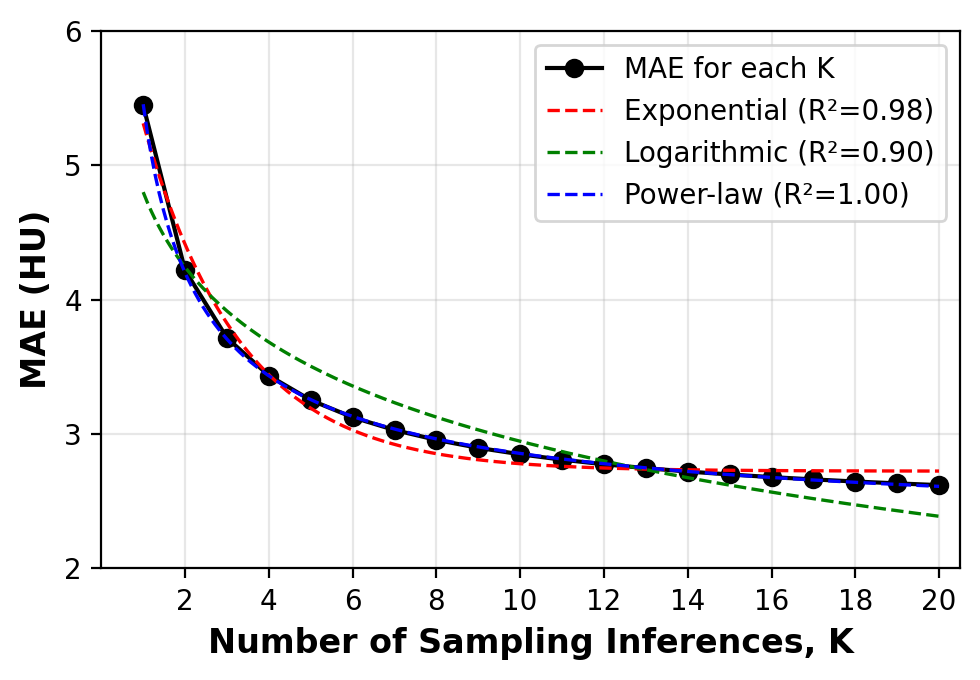

In [12]:
fig, ax = plt.subplots(figsize=(5, 3.5), dpi=200)  # 用ax对象更易控制坐标轴

# 1. 绘制原始数据点与拟合曲线（保留原样式）
ax.plot(x, y, 'ko-', label='MAE for each K', linewidth=1.5, markersize=6)  # 黑色圆点+实线
ax.plot(x_fit, y_exp, 'r--', label=f'Exponential (R²={r2_exp:.2f})', linewidth=1.2)  # 红色虚线
ax.plot(x_fit, y_log, 'g--', label=f'Logarithmic (R²={r2_log:.2f})', linewidth=1.2)  # 绿色虚线
ax.plot(x_fit, y_pow, 'b--', label=f'Power-law (R²={r2_pow:.2f})', linewidth=1.2)  # 蓝色虚线

# 2. 绘制FBP数据点（灰色圆点，K=1右侧，x=1.5避免重叠）
# fbp_mae = 16.7
# ax.plot(1.5, fbp_mae, 'o', color='red', markersize=6, label=f'FBP (MAE={fbp_mae} HU)')

# 3. 调整x轴：范围1-20，刻度2/4...20
ax.set_xlim(0, 20.5)
ax.set_xticks(np.arange(2, 21, 2))  # 从2开始，间隔2到20
ax.set_xlabel('Number of Sampling Inferences, K', fontsize=12, fontweight='bold')

# 4. 调整y轴：范围11-17，刻度11/12...17
ax.set_ylim(2, 6)
ax.set_yticks(np.arange(2, 6.1, 1))  # 从11开始，间隔1到17
ax.set_ylabel('MAE (HU)', fontsize=12, fontweight='bold')

# 5. 保留网格与图例（原样式优化）
ax.grid(True, alpha=0.3, linestyle='-')  # 网格线透明度降低，更清晰
ax.legend(fontsize=10, frameon=True, loc='upper right')  # 图例位置右上，带边框


# -------------------------- 4. 保存/显示图片 --------------------------
plt.tight_layout()  # 避免标签截断
# plt.savefig('mae_fitting_with_fbp.png', dpi=300, bbox_inches='tight')
# plt.show()  # 调试时取消注释
plt.savefig('/host/d/projects/denoising/results/mae_K_fitting_brainCT.pdf', dpi=300, bbox_inches='tight')

### SSIM

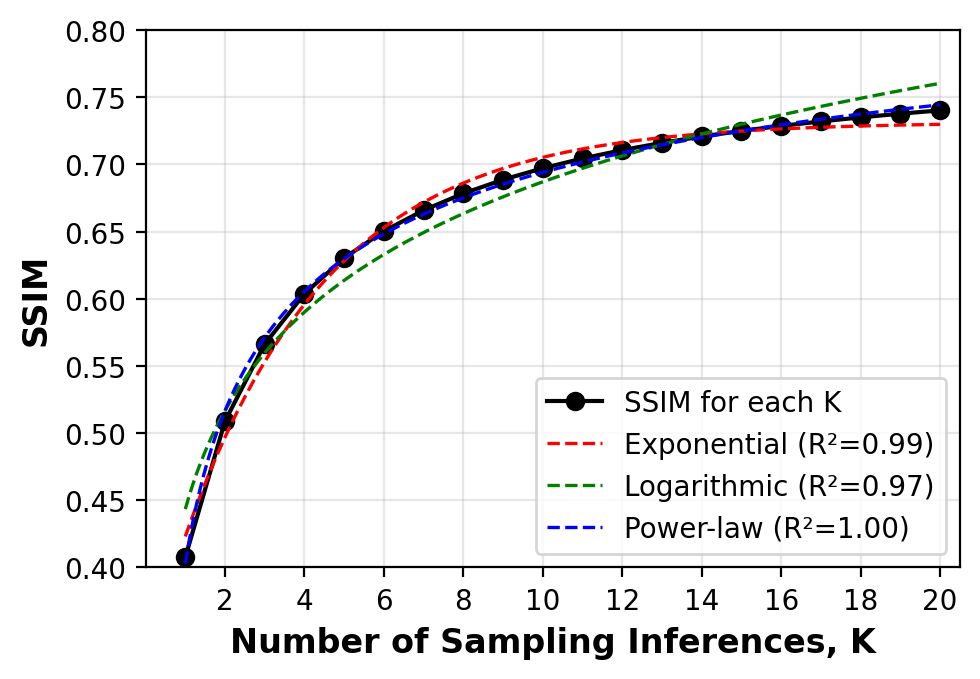

In [15]:
y = np.asarray(ssim_list)  # y轴为SSIM


# -------------------------- 2. 定义拟合函数与曲线拟合（逻辑不变） --------------------------
def log_func(x, a, b):
    return a * np.log(x) + b

def power_func(x, a, b, c):
    return a * x**(-b) + c

def exp_func(x, a, b, c):
    return a * np.exp(-b * x) + c

# 曲线拟合（SSIM是上升趋势，拟合参数会自动适配）
popt_log, _ = curve_fit(log_func, x, y)
popt_pow, _ = curve_fit(power_func, x, y, maxfev=10000)
popt_exp, _ = curve_fit(exp_func, x, y, maxfev=10000)

# 生成拟合曲线
x_fit = np.linspace(1, 20, 200)
y_log = log_func(x_fit, *popt_log)
y_pow = power_func(x_fit, *popt_pow)
y_exp = exp_func(x_fit, *popt_exp)

# 计算R²
r2_exp = r2_score(y, exp_func(x, *popt_exp))
r2_log = r2_score(y, log_func(x, *popt_log))
r2_pow = r2_score(y, power_func(x, *popt_pow))


# -------------------------- 3. 绘图配置（适配SSIM的y轴范围） --------------------------
fig, ax = plt.subplots(figsize=(5,3.5), dpi=200)

# 1. 绘制原始数据与拟合曲线
ax.plot(x, y, 'ko-', label='SSIM for each K', linewidth=1.5, markersize=6)
ax.plot(x_fit, y_exp, 'r--', label=f'Exponential (R²={r2_exp:.2f})', linewidth=1.2)
ax.plot(x_fit, y_log, 'g--', label=f'Logarithmic (R²={r2_log:.2f})', linewidth=1.2)
ax.plot(x_fit, y_pow, 'b--', label=f'Power-law (R²={r2_pow:.2f})', linewidth=1.2)

# 2. 绘制FBP的SSIM数据点（参考你之前表格的FBP SSIM值：0.744）
# fbp_ssim = 0.744  # 对应FBP的SSIM值
# ax.plot(1.5, fbp_ssim, 'o', color='gray', markersize=6, label=f'FBP (SSIM={fbp_ssim})')

# 3. 调整x轴（与之前一致）
ax.set_xlim(0, 20.5)
ax.set_xticks(np.arange(2, 21, 2))
ax.set_xlabel('Number of Sampling Inferences, K', fontsize=12, fontweight='bold')

# 4. 调整y轴（适配SSIM范围：假设数据在0.7~0.85之间）
ax.set_ylim(0.40, 0.80)
ax.set_yticks(np.arange(0.40, 0.81, 0.05))  # 刻度间隔0.05
ax.set_ylabel('SSIM', fontsize=12, fontweight='bold')

# 5. 网格与图例
ax.grid(True, alpha=0.3, linestyle='-')
ax.legend(fontsize=10, frameon=True, loc='lower right')  # 图例移至右下（适配SSIM上升趋势）


# -------------------------- 4. 保存图片 --------------------------
plt.tight_layout()
# plt.savefig('ssim_fitting_with_fbp.png', dpi=300, bbox_inches='tight')
# plt.show()
plt.savefig('/host/d/projects/denoising/results/ssim_K_fitting_brainCT.pdf', dpi=300, bbox_inches='tight')

### noise variance

In [3]:
build_sheet =  Build_list.Build_thinsliceCT(os.path.join('/gpfs/work/aac/xingyiyao23/Data/brain_CT/Patient_lists/fixedCT_static_simulation_train_test_gaussian_xjtlu.xlsx'))
_,patient_id_list,patient_subid_list,random_num_list, condition_list, x0_list = build_sheet.__build__(batch_list = [5]) 
print('total cases:', patient_id_list.shape[0])
n = ff.get_X_numbers_in_interval(total_number = patient_id_list.shape[0],start_number = 0,end_number = 1, interval = 2)
print('total number:', n.shape[0])

total cases: 32
total number: 16


In [ ]:
for i in range(0,5):#n.shape[0]):
    variance_list_all = []
    patient_id = patient_id_list[n[i]]
    patient_subid = patient_subid_list[n[i]]
    random_n = random_num_list[n[i]]
    print(patient_id,  patient_subid, random_n)

    # reference image
    gt_file =  os.path.join('/gpfs/work/aac/xingyiyao23/projects/unsupervised_gaussian_brainCT/pred_images', patient_id, patient_subid,'random_'+str(random_n), 'epoch61_1/gt_img.nii.gz')
    gt_img = nb.load(gt_file).get_fdata()

    # # our method 
    variance_list = []
    for k in range(1,21):
        unsupervised_beta0_avg_file = os.path.join('/gpfs/work/aac/xingyiyao23/projects/unsupervised_gaussian_brainCT/pred_images', patient_id,patient_subid, 'random_'+str(random_n), 'epoch61avg/pred_img_scans' + str(k) + '.nii.gz')
        unsupervised_beta0_avg_img = nb.load(unsupervised_beta0_avg_file).get_fdata()

        noise = unsupervised_beta0_avg_img - gt_img
        # pick the last slice, center 30x30 ROI
        noise_last_slice = noise[noise.shape[0]//2-15:noise.shape[0]//2+15, noise.shape[1]//2-15:noise.shape[1]//2+15, -1]
        # calculate the variance
        variance = np.var(noise_last_slice)
        if k == 1:
            initial_variance = variance
        variance_list.append(variance)
        print('K', k, ' variance:', variance, ' should be ', initial_variance / (k**0.5), ' * (k**0.5)', variance * ((k)**0.5))
    variance_list_all.append(variance_list)

00214841 0000455418 0
K 1  variance: 5.97872786184455  should be  5.97872786184455  * (k**0.5) 5.97872786184455
K 2  variance: 5.888320671537473  should be  4.227599013979229  * (k**0.5) 8.327342953290145
K 3  variance: 5.497281378503159  should be  3.4518201404474667  * (k**0.5) 9.521570651069746
K 4  variance: 5.882112602313053  should be  2.989363930922275  * (k**0.5) 11.764225204626106
K 5  variance: 5.637781244027001  should be  2.673768383611277  * (k**0.5) 12.606462103917705


KeyboardInterrupt: 

In [7]:
for i in range(0, len(variance_list)):
    print('k is ', i+1, ' variance is ', variance_list[i], ' * K**0.5 is ', variance_list[i] * ((i+1)**0.5))

k is  1  variance is  31.233434514006277  * K**0.5 is  31.233434514006277
k is  2  variance is  18.80212698853818  * K**0.5 is  26.590222988651895
k is  3  variance is  14.38318105371975  * K**0.5 is  24.91240035950467
k is  4  variance is  11.75120727732801  * K**0.5 is  23.50241455465602
k is  5  variance is  10.308349115143093  * K**0.5 is  23.050169357259765
k is  6  variance is  9.874891580180263  * K**0.5 is  24.18844563674752
k is  7  variance is  8.9204017699697  * K**0.5 is  23.60116467812023
k is  8  variance is  8.997261405361845  * K**0.5 is  25.44809820735747
k is  9  variance is  8.296718564631165  * K**0.5 is  24.890155693893497
k is  10  variance is  7.5203076335614325  * K**0.5 is  23.78130082720505
k is  11  variance is  7.218233081928651  * K**0.5 is  23.940170782088025
k is  12  variance is  6.862493455732391  * K**0.5 is  23.772374663874846
k is  13  variance is  6.692489503716837  * K**0.5 is  24.130114066155603
k is  14  variance is  6.465938315730475  * K**0.5 i